1/3 正在构建高维 GUE 随机矩阵...
2/3 正在现场计算前 1000 个真实的黎曼零点 (请稍候 5-10 秒)...
3/3 正在绘制终极对比图...


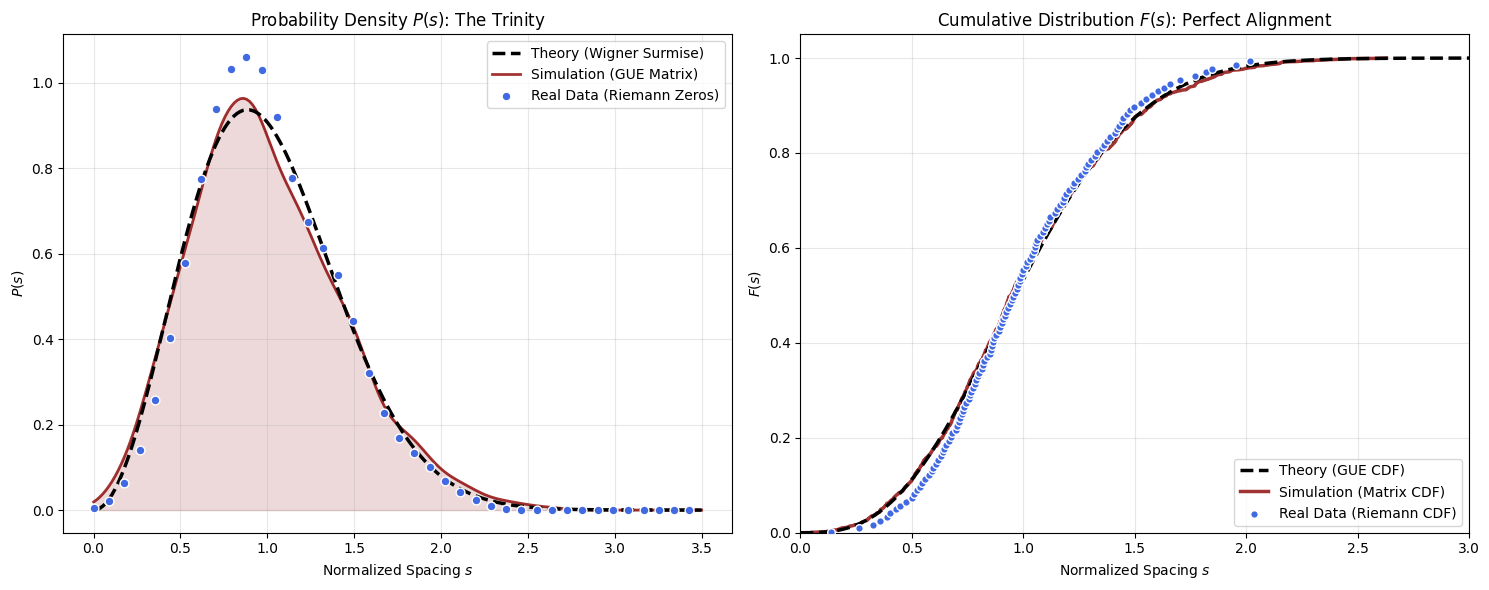

运行完毕！享受真理的视觉冲击吧。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.special import erf
import mpmath  # 用于高精度计算真实的黎曼零点

# ==========================================
# 1. 构造仿真：GUE 随机矩阵 (上帝的骰子)
# ==========================================
print("1/3 正在构建高维 GUE 随机矩阵...")
N_matrix = 2500
A = np.random.randn(N_matrix, N_matrix) + 1j * np.random.randn(N_matrix, N_matrix)
H = (A + A.conj().T) / 2.0 
eigvals = np.linalg.eigvalsh(H)

# 提取矩阵的体区 (Bulk) 特征值并展开
keep_ratio = 0.6
start_idx = int(N_matrix * (1 - keep_ratio) / 2)
end_idx = int(N_matrix * (1 + keep_ratio) / 2)
bulk_eigvals = eigvals[start_idx:end_idx]

s_matrix = np.diff(bulk_eigvals)
s_matrix = s_matrix / np.mean(s_matrix)

# ==========================================
# 2. 提取真实物理量：计算黎曼 ζ 函数零点
# ==========================================
print("2/3 正在现场计算前 1000 个真实的黎曼零点 (请稍候 5-10 秒)...")
N_zeros = 1000
# mpmath.zetazero(n) 会返回第 n 个零点 (如 0.5 + 14.1347i)，我们只取虚部
zeros = np.array([float(mpmath.zetazero(i).imag) for i in range(1, N_zeros + 1)])

# 【核心教学点】：黎曼-冯·曼戈尔特公式展开 (Riemann-von Mangoldt Unfolding)
# 真实的黎曼零点越来越密，密度函数为 rho(t) ≈ (1/2π) * ln(t / 2π)
# 我们用这个真实的数学密度，把零点间距“拉平”
spacings_riemann = np.diff(zeros)
rho = np.log(zeros[:-1] / (2 * np.pi)) / (2 * np.pi)
s_riemann = spacings_riemann * rho

# 确保均值严格对齐到 1，以消除前 1000 个零点的低阶有限尺效应
s_riemann = s_riemann / np.mean(s_riemann)

# ==========================================
# 3. 定义理论解析函数 (理论极限)
# ==========================================
def gue_pdf(x):
    return (32 / (np.pi**2)) * (x**2) * np.exp(-(4 / np.pi) * (x**2))

def gue_cdf(x):
    return erf(2 * x / np.sqrt(np.pi)) - (4 * x / np.pi) * np.exp(-4 * x**2 / np.pi)

# ==========================================
# 4. 绘图：真理的三位一体 (The Trinity)
# ==========================================
print("3/3 正在绘制终极对比图...")
plt.figure(figsize=(15, 6))
x_plot = np.linspace(0.001, 3.5, 200)

# --- 左图：PDF (KDE) 对决 ---
plt.subplot(1, 2, 1)

# 1. 理论曲线 (黑线)
plt.plot(x_plot, gue_pdf(x_plot), 'k--', lw=2.5, zorder=3, label='Theory (Wigner Surmise)')

# 2. 矩阵仿真 (红色填充)
kde_matrix = gaussian_kde(s_matrix)
plt.plot(x_plot, kde_matrix(x_plot), color='darkred', lw=2, alpha=0.8, label='Simulation (GUE Matrix)')
plt.fill_between(x_plot, kde_matrix(x_plot), alpha=0.15, color='darkred')

# 3. 真实黎曼零点 (蓝色散点)
kde_riemann = gaussian_kde(s_riemann)
# 为了视觉效果，我们每隔 5 个点画一个散点
plt.scatter(x_plot[::5], kde_riemann(x_plot[::5]), color='royalblue', s=40, zorder=4, 
            edgecolor='white', label='Real Data (Riemann Zeros)')

plt.title(r"Probability Density $P(s)$: The Trinity")
plt.xlabel(r"Normalized Spacing $s$")
plt.ylabel(r"$P(s)$")
plt.legend()
plt.grid(alpha=0.3)

# --- 右图：CDF (累积分布) 终极咬合 ---
plt.subplot(1, 2, 2)

# 1. 理论曲线 (黑线)
plt.plot(x_plot, gue_cdf(x_plot), 'k--', lw=2.5, zorder=3, label='Theory (GUE CDF)')

# 2. 矩阵仿真 (红线)
s_matrix_sorted = np.sort(s_matrix)
y_ecdf_matrix = np.arange(1, len(s_matrix_sorted) + 1) / len(s_matrix_sorted)
plt.plot(s_matrix_sorted, y_ecdf_matrix, color='darkred', lw=2.5, alpha=0.8, label='Simulation (Matrix CDF)')

# 3. 真实黎曼零点 (蓝色散点)
s_riemann_sorted = np.sort(s_riemann)
y_ecdf_riemann = np.arange(1, len(s_riemann_sorted) + 1) / len(s_riemann_sorted)
# 用散点画出黎曼零点的 CDF 阶梯
plt.scatter(s_riemann_sorted[::8], y_ecdf_riemann[::8], color='royalblue', s=30, zorder=4,
            edgecolor='white', label='Real Data (Riemann CDF)')

plt.title(r"Cumulative Distribution $F(s)$: Perfect Alignment")
plt.xlabel(r"Normalized Spacing $s$")
plt.ylabel(r"$F(s)$")
plt.xlim(0, 3)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("运行完毕！享受真理的视觉冲击吧。")